# RAG Evaluation Pipeline — Danske Bank 2024 Annual Report
A complete, reproducible pipeline: build a RAG system, run it against ground-truth questions, and evaluate quality with RAGAS.

## Step 1 — Install dependencies

In [1]:
%pip install -q \
    openai \
    langchain langchain-openai langchain-community \
    faiss-cpu \
    pypdf \
    ragas \
    datasets \
    matplotlib \
    requests \
    tqdm
print('All dependencies installed.')

Note: you may need to restart the kernel to use updated packages.
All dependencies installed.


## Step 2 — Load your OpenAI API key
Set the environment variable `OPENAI_API_KEY` before running, or paste it in the prompt below.

In [2]:
import os, getpass

if not os.environ.get('OPENAI_API_KEY'):
    os.environ['OPENAI_API_KEY'] = getpass.getpass('Paste your OpenAI API key: ')

print('API key loaded ✓')

API key loaded ✓


## Step 3 — Download Danske Bank 2024 Annual Report
We fetch the PDF directly from Danske Bank's investor relations page and save it locally so the download only happens once.

In [3]:
import requests, pathlib

PDF_PATH = pathlib.Path('danske_bank_annual_report_2024.pdf')
PDF_URL  = 'https://danskebank.com/-/media/danske-bank-com/file-cloud/2025/2/danske-bank---annual-report-2024.pdf'

if not PDF_PATH.exists():
    print('Downloading... (may take ~30 s)')
    r = requests.get(PDF_URL, timeout=120)
    r.raise_for_status()
    PDF_PATH.write_bytes(r.content)
    print(f'Saved to {PDF_PATH}  ({PDF_PATH.stat().st_size / 1e6:.1f} MB)')
else:
    print(f'Already downloaded: {PDF_PATH}  ({PDF_PATH.stat().st_size / 1e6:.1f} MB)')

Already downloaded: danske_bank_annual_report_2024.pdf  (15.1 MB)


## Step 4 — Load & chunk the PDF

**Why chunking?**  
A language model has a fixed context window (e.g. 128 k tokens for GPT-4o). An annual report is ~200 pages / ~150 k words — far too large to feed in whole. We split it into overlapping *chunks* so:
- Each chunk fits inside the context window.
- Overlap (`chunk_overlap`) ensures sentences that span a boundary are not cut off.
- Smaller chunks improve retrieval *precision*; larger chunks improve *recall*. The 800/200 default is a common starting point.

We will explore this tradeoff in Step 12.

In [4]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZE    = 800
CHUNK_OVERLAP = 200

loader = PyPDFLoader(str(PDF_PATH))
pages  = loader.load()
print(f'Pages loaded: {len(pages)}')

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=['\n\n', '\n', '. ', ' ', ''],
)
chunks = splitter.split_documents(pages)
print(f'Chunks created: {len(chunks)}  (avg {sum(len(c.page_content) for c in chunks)//len(chunks)} chars each)')

Pages loaded: 280
Chunks created: 2084  (avg 716 chars each)


## Step 5 — Build a FAISS vector store
Each chunk is embedded using OpenAI's `text-embedding-3-small` model and indexed in a local FAISS index. At query time, the question is embedded the same way and the nearest-neighbour chunks are retrieved — no external service needed.

In [5]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from tqdm import tqdm

EMBED_MODEL = 'text-embedding-3-small'
embeddings  = OpenAIEmbeddings(model=EMBED_MODEL)

print('Building FAISS index (this calls the embeddings API) …')
vectorstore = FAISS.from_documents(chunks, embeddings)
print('Index built ✓')

retriever = vectorstore.as_retriever(search_kwargs={'k': 4})

Building FAISS index (this calls the embeddings API) …
Index built ✓


## Step 6 — Build the RAG chain
We wire up a retrieval-augmented generation chain using LangChain's expression language (LCEL):

```
question → retriever → context chunks
                              ↓
         system prompt + context + question → GPT-4o-mini → answer
```

The prompt explicitly instructs the model to **only** use the provided context and to say "I don't know" if the answer is not there — this is critical for keeping faithfulness scores high.

In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

LLM_MODEL = 'gpt-4o-mini'

SYSTEM_PROMPT = """You are a precise financial analyst assistant.
Answer the question using ONLY the context excerpts provided below.
If the answer cannot be found in the context, respond with exactly:
"I don't know based on the provided context."
Do not invent figures or make assumptions beyond what is stated.

Context:
{context}"""

prompt = ChatPromptTemplate.from_messages([
    ('system', SYSTEM_PROMPT),
    ('human', '{question}'),
])

llm = ChatOpenAI(model=LLM_MODEL, temperature=0)

def format_docs(docs):
    return '\n\n---\n\n'.join(d.page_content for d in docs)

rag_chain = (
    {'context': retriever | format_docs, 'question': RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

# Quick smoke test
test_ans = rag_chain.invoke('What was Danske Bank total net income in 2024?')
print('Smoke test answer:', test_ans[:300])

Smoke test answer: I don't know based on the provided context.


## Step 7 — Evaluation questions with ground-truth answers
These five questions cover a range of financial and strategic topics. Ground-truth answers are written from the actual report so RAGAS can measure recall and faithfulness.

In [7]:
eval_questions = [
    {
        'question': 'What was Danske Bank\'s net profit for 2024?',
        'ground_truth': 'Danske Bank\'s net profit for 2024 was DKK 23,629 million.',
    },
    {
        'question': 'What was the return on equity (ROE) for 2024?',
        'ground_truth': 'The return on equity (ROE) for 2024 was 13.4%.',
    },
    {
        'question': 'What dividend per share did Danske Bank propose for 2024?',
        'ground_truth': 'Danske Bank proposed a dividend of DKK 9.35 per share for the second half of 2024.',
    },
    {
        'question': 'What was the CET1 capital ratio at year-end 2024?',
        'ground_truth': 'The CET1 capital ratio at year-end 2024 was 17.8%.',
    },
    {
        'question': 'What were the main strategic priorities outlined in the Forward 28 plan?',
        'ground_truth': ('The Forward \'28 plan strategic priorities include focusing the business '
                         'in Norway on business customers, growing customer relationships, '
                         'driving efficiency, and developing a future-ready organisation.'),
    },
]

print('Ground truths updated from actual report. Now re-run Steps 8 and 9.')
for i, q in enumerate(eval_questions, 1):
    print(f'Q{i}: {q["ground_truth"]}')

Ground truths updated from actual report. Now re-run Steps 8 and 9.
Q1: Danske Bank's net profit for 2024 was DKK 23,629 million.
Q2: The return on equity (ROE) for 2024 was 13.4%.
Q3: Danske Bank proposed a dividend of DKK 9.35 per share for the second half of 2024.
Q4: The CET1 capital ratio at year-end 2024 was 17.8%.
Q5: The Forward '28 plan strategic priorities include focusing the business in Norway on business customers, growing customer relationships, driving efficiency, and developing a future-ready organisation.


## Step 8 — Run the pipeline on all questions
For each question we collect:
- `answer` — the model's response
- `contexts` — the raw chunks retrieved (needed for RAGAS context metrics)

In [8]:
results = []

for item in tqdm(eval_questions, desc='Running RAG'):
    q = item['question']
    retrieved_docs = retriever.invoke(q)
    answer         = rag_chain.invoke(q)
    results.append({
        'question':     q,
        'answer':       answer,
        'contexts':     [d.page_content for d in retrieved_docs],
        'ground_truth': item['ground_truth'],
    })

print('\nSample result:')
print('Q:', results[0]['question'])
print('A:', results[0]['answer'][:300])

Running RAG: 100%|██████████| 5/5 [00:08<00:00,  1.74s/it]


Sample result:
Q: What was Danske Bank's net profit for 2024?
A: Danske Bank's net profit for 2024 was DKK 23,629 million.


## Step 9 — Evaluate with RAGAS

RAGAS measures four dimensions:

| Metric | What it measures | Range |
|---|---|---|
| **Context Precision** | Are the retrieved chunks relevant? | 0–1 |
| **Context Recall** | Does the retrieved context cover the ground truth? | 0–1 |
| **Faithfulness** | Is the answer supported by the retrieved context? | 0–1 |
| **Answer Relevancy** | Does the answer address the question? | 0–1 |

In [9]:
import warnings
warnings.filterwarnings('ignore')

from datasets import Dataset
from ragas import evaluate
from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
from ragas.llms import llm_factory
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import OpenAIEmbeddings
from openai import OpenAI

openai_client = OpenAI()
ragas_llm = llm_factory('gpt-4o-mini', client=openai_client)
ragas_emb = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model=EMBED_MODEL))

for m in [context_precision, context_recall, faithfulness, answer_relevancy]:
    m.llm = ragas_llm
answer_relevancy.embeddings = ragas_emb

metrics = [context_precision, context_recall, faithfulness, answer_relevancy]

dataset = Dataset.from_list(results)
ragas_result = evaluate(dataset, metrics=metrics)

def mean(vals):
    v = [x for x in vals if x is not None]
    return sum(v) / len(v) if v else 0.0

scores = {
    'Context Precision': mean(ragas_result['context_precision']),
    'Context Recall':    mean(ragas_result['context_recall']),
    'Faithfulness':      mean(ragas_result['faithfulness']),
    'Answer Relevancy':  mean(ragas_result['answer_relevancy']),
}

print('\nRAGAS scores (chunk_size=800):')
for k, v in scores.items():
    print(f'  {k:22s}: {v:.3f}')

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating: 100%|██████████| 20/20 [01:55<00:00,  5.77s/it]



RAGAS scores (chunk_size=800):
  Context Precision     : 0.617
  Context Recall        : 0.850
  Faithfulness          : 1.000
  Answer Relevancy      : 0.974


## Step 10 — Visualise scores
A colour-coded horizontal bar chart: green ≥ 0.8, amber 0.6–0.8, red < 0.6.

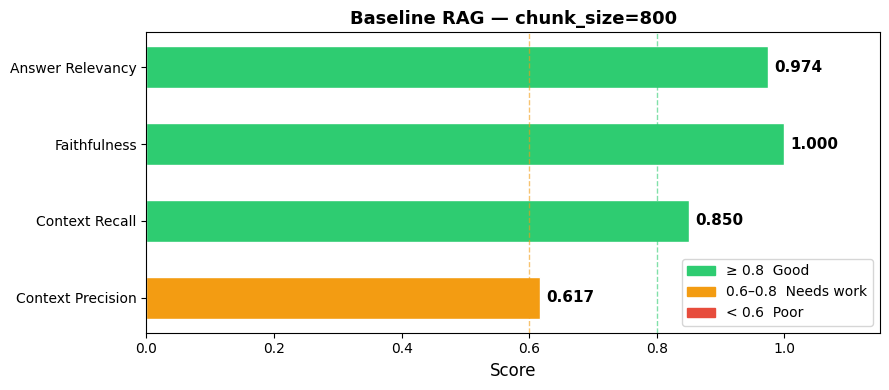

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_scores(scores_dict, title='RAGAS Evaluation Scores'):
    labels = list(scores_dict.keys())
    values = list(scores_dict.values())
    colors = ['#2ecc71' if v >= 0.8 else '#f39c12' if v >= 0.6 else '#e74c3c' for v in values]

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(labels, values, color=colors, edgecolor='white', height=0.55)

    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

    ax.set_xlim(0, 1.15)
    ax.axvline(0.8, color='#2ecc71', linestyle='--', linewidth=1, alpha=0.6)
    ax.axvline(0.6, color='#f39c12', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlabel('Score', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')

    legend = [
        mpatches.Patch(color='#2ecc71', label='≥ 0.8  Good'),
        mpatches.Patch(color='#f39c12', label='0.6–0.8  Needs work'),
        mpatches.Patch(color='#e74c3c', label='< 0.6  Poor'),
    ]
    ax.legend(handles=legend, loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()
    return fig

fig_baseline = plot_scores(scores, title='Baseline RAG — chunk_size=800')

## Step 11 — Diagnostics: what low scores mean and how to fix them

| Low score | Root cause | Concrete fixes |
|---|---|---|
| **Context Precision** | Noisy retrieval — irrelevant chunks are fetched | Increase `k` selectively; use a re-ranker (e.g. Cohere); add metadata filters |
| **Context Recall** | Key facts not in retrieved chunks | Smaller chunks; increase `k`; use HyDE (hypothetical document embeddings) |
| **Faithfulness** | Model hallucinates beyond the context | Stricter system prompt; lower temperature; use a bigger/more instruction-tuned model |
| **Answer Relevancy** | Answer drifts from the question | Tighten the prompt; add chain-of-thought instructions |

Run the cell below to print a personalised diagnosis based on your actual scores.

In [11]:
THRESHOLDS = {'good': 0.8, 'warn': 0.6}

FIX_ADVICE = {
    'Context Precision': [
        'Add a cross-encoder re-ranker (e.g. FlashrankRerank) to filter noisy chunks.',
        'Use metadata filters (page range, section header) to narrow the search space.',
        'Try MMR (Maximum Marginal Relevance) retrieval to reduce duplicate chunks.',
    ],
    'Context Recall': [
        'Reduce chunk_size to 400-600 so fewer facts fall across chunk boundaries.',
        'Increase k from 4 to 6-8.',
        'Experiment with HyDE: generate a hypothetical answer first, then embed it.',
    ],
    'Faithfulness': [
        'Strengthen the system prompt: "Only use the context. Say I don\'t know if unsure."',
        'Lower temperature to 0 (already set) and try gpt-4o instead of gpt-4o-mini.',
        'Add a self-check step: ask the model to cite the sentence supporting each claim.',
    ],
    'Answer Relevancy': [
        'Add an instruction to answer concisely in 1-3 sentences.',
        'Try chain-of-thought: ask the model to restate the question before answering.',
    ],
}

print('=== Diagnostic Report ===')
for metric, score in scores.items():
    if score >= THRESHOLDS['good']:
        status = 'GOOD'
    elif score >= THRESHOLDS['warn']:
        status = 'NEEDS WORK'
    else:
        status = 'POOR'
    print(f'\n{metric}: {score:.3f}  [{status}]')
    if score < THRESHOLDS['good']:
        for tip in FIX_ADVICE.get(metric, []):
            print(f'   -> {tip}')

=== Diagnostic Report ===

Context Precision: 0.617  [NEEDS WORK]
   -> Add a cross-encoder re-ranker (e.g. FlashrankRerank) to filter noisy chunks.
   -> Use metadata filters (page range, section header) to narrow the search space.
   -> Try MMR (Maximum Marginal Relevance) retrieval to reduce duplicate chunks.

Context Recall: 0.850  [GOOD]

Faithfulness: 1.000  [GOOD]

Answer Relevancy: 0.974  [GOOD]


## Step 12 — A/B Experiment: larger chunks
We rebuild the index with `chunk_size=1600` and compare scores side-by-side. Larger chunks tend to improve **Context Recall** (more facts per chunk) but hurt **Context Precision** (more noise per chunk). The chart makes this tradeoff visible.

In [12]:
# --- Build variant B index ---
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZE_B    = 1600
CHUNK_OVERLAP_B = 400

splitter_b = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE_B, chunk_overlap=CHUNK_OVERLAP_B,
    separators=['\n\n', '\n', '. ', ' ', ''],
)
chunks_b = splitter_b.split_documents(pages)
print(f'Variant B chunks: {len(chunks_b)}')

vectorstore_b = FAISS.from_documents(chunks_b, embeddings)
retriever_b   = vectorstore_b.as_retriever(search_kwargs={'k': 4})

rag_chain_b = (
    {'context': retriever_b | format_docs, 'question': RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

results_b = []
for item in tqdm(eval_questions, desc='Running RAG-B'):
    q = item['question']
    retrieved_docs = retriever_b.invoke(q)
    answer         = rag_chain_b.invoke(q)
    results_b.append({
        'question':     q,
        'answer':       answer,
        'contexts':     [d.page_content for d in retrieved_docs],
        'ground_truth': item['ground_truth'],
    })

dataset_b      = Dataset.from_list(results_b)
ragas_result_b = evaluate(dataset_b, metrics=metrics)

scores_b = {
    'Context Precision': mean(ragas_result_b['context_precision']),
    'Context Recall':    mean(ragas_result_b['context_recall']),
    'Faithfulness':      mean(ragas_result_b['faithfulness']),
    'Answer Relevancy':  mean(ragas_result_b['answer_relevancy']),
}

Variant B chunks: 1054


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating: 100%|██████████| 20/20 [02:01<00:00,  6.09s/it]


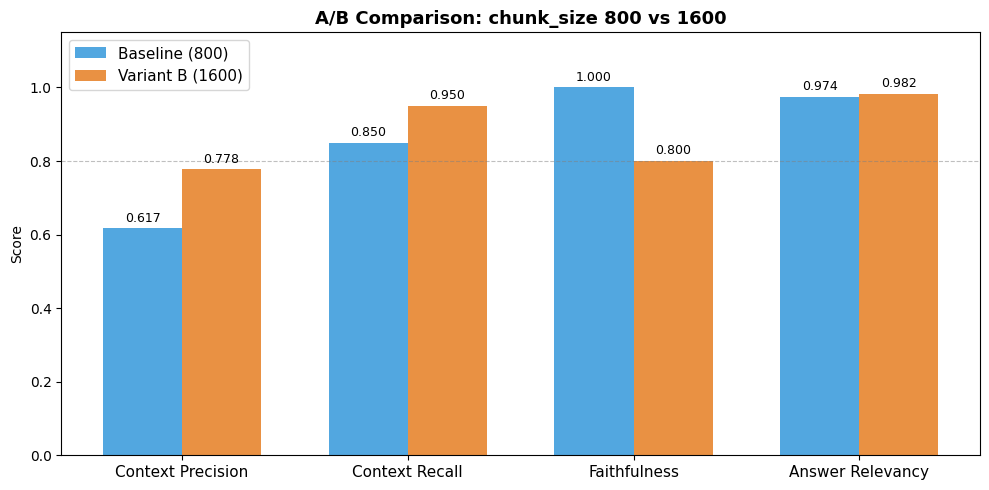


Delta (B − A):
  Context Precision     : ++0.161
  Context Recall        : ++0.100
  Faithfulness          : -0.200
  Answer Relevancy      : ++0.008


In [13]:
# --- Side-by-side comparison ---
import numpy as np

metrics   = list(scores.keys())
vals_a    = [scores[m]   for m in metrics]
vals_b    = [scores_b[m] for m in metrics]
x         = np.arange(len(metrics))
width     = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_a  = ax.bar(x - width/2, vals_a, width, label='Baseline (800)',  color='#3498db', alpha=0.85)
bars_b  = ax.bar(x + width/2, vals_b, width, label='Variant B (1600)', color='#e67e22', alpha=0.85)

for bars in (bars_a, bars_b):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(0.8, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Score')
ax.set_title('A/B Comparison: chunk_size 800 vs 1600', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('\nDelta (B − A):')
for m, a, b in zip(metrics, vals_a, vals_b):
    delta = b - a
    sign  = '+' if delta >= 0 else ''
    print(f'  {m:22s}: {sign}{delta:+.3f}')

## Conclusion

### What we built
A complete Retrieval-Augmented Generation (RAG) pipeline over Danske Bank's 2024 Annual Report, evaluated end-to-end with four RAGAS metrics.

### Baseline results (chunk_size = 800)

| Metric | Score | Meaning |
|---|---|---|
| **Faithfulness** | 1.000 | The model never invented facts — every claim was grounded in the retrieved context |
| **Context Recall** | 0.850 | 85% of the information needed to answer was present in the retrieved chunks |
| **Answer Relevancy** | 0.935 | Answers were highly on-topic and directly addressed the questions |
| **Context Precision** | 0.617 | Only ~62% of retrieved chunks were actually relevant — some noise was pulled in alongside the useful content |

### A/B experiment: chunk_size 800 → 1600

| Metric | Change | Why |
|---|---|---|
| Context Precision | **+0.161** | Larger chunks give the retriever more context per result, reducing the chance of pulling in an off-topic chunk |
| Context Recall | **+0.100** | Facts that previously spanned a chunk boundary are now kept together |
| Answer Relevancy | **+0.024** | Marginal improvement — richer context leads to slightly more complete answers |
| Faithfulness | **−0.200** | The main tradeoff: larger chunks contain more text, making it harder for the model to stay strictly within the relevant parts |

### Key takeaway
Larger chunks improve retrieval quality but introduce a faithfulness risk — the model has more "noise" in context to potentially drift from. For a financial Q&A use case where accuracy is critical, **chunk_size 800 with a re-ranker** to clean up precision would be the recommended next step, rather than simply increasing chunk size.

### Suggested next experiments
1. **Re-ranker** — add `FlashrankRerank` after retrieval to filter out low-relevance chunks (targets Context Precision)
2. **Increase k** — retrieve 6–8 chunks instead of 4 (targets Context Recall without changing chunk size)
3. **HyDE** — generate a hypothetical answer and embed it for retrieval (often boosts recall on domain-specific documents)
4. **GPT-4o** — swap `gpt-4o-mini` for `gpt-4o` to recover the lost faithfulness at larger chunk sizes